# Introduction

We are now moving to the final part of the workshop, which involves formulating business recommendations. Our tasks are:
- Determining a global betting odds,
- Dividing the dataset into categories: A, B, C, D, where A is the best group and D is the weakest group,
- Determining the risk of odds based on accepted parameters for each category.

As the last task, in a discussion format, we must consider the fact that we are a new betting company. When formulating our recommendations, we need to identify the risks that may affect our operations. We will perform this task together in a brainstorming session.

# Notebook Configuration

## Import necessary libraries

In [5]:
#C:\Users\rdpre\Workshop_-_files\data\processed\hockey_teams.csv

# Notebook 4 – Business Recommendations
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"C:\Users\rdpre\Workshop_-_files\data\processed\hockey_teams.csv", sep=";")

df.head()
df.info()

# Pro zobrazení grafů v notebooku
%matplotlib inline

# Volitelně: nastavení stylu grafů
sns.set(style="whitegrid")
# Výpočet globální průměrné výhernosti
global_victory_pct = df["victory_percentage"].mean()

print(f"🌍 Globální průměrná výhernost: {round(global_victory_pct, 3)}")
# Návrh základního kurzu
base_odds = round(1 / global_victory_pct, 2)
print(f"💰 Návrh základního kurzu: {base_odds}")
# Rozdělení týmů do kategorií A–D podle výhernosti
df["category"] = pd.qcut(df["victory_percentage"], q=4, labels=["D", "C", "B", "A"])

# Výpis počtu týmů v každé kategorii
print("📊 Počet týmů v kategoriích:")
print(df["category"].value_counts().sort_index())

# Výpočet průměrné výhernosti a návrh kurzu pro každou kategorii
category_stats = df.groupby("category")["victory_percentage"].mean().sort_index().reset_index()
category_stats["odds"] = (1 / category_stats["victory_percentage"]).round(2)

print("📈 Návrh kurzů podle kategorií:")
print(category_stats)

# Výpočet průměrné výhernosti a návrh kurzu pro každou kategorii
category_stats = df.groupby("category")["victory_percentage"].mean().sort_index().reset_index()
category_stats["odds"] = (1 / category_stats["victory_percentage"]).round(2)

print("📈 Návrh kurzů podle kategorií:")
print(category_stats)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 582 entries, 0 to 581
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Team Name           582 non-null    object 
 1   Year                582 non-null    int64  
 2   Wins                582 non-null    int64  
 3   Losses              582 non-null    int64  
 4   OT Losses           358 non-null    float64
 5   Win %               582 non-null    float64
 6   Goals For (GF)      582 non-null    int64  
 7   Goals Against (GA)  582 non-null    int64  
 8   + / -               582 non-null    int64  
 9   goals_ratio         582 non-null    float64
 10  victory_percentage  358 non-null    float64
dtypes: float64(4), int64(6), object(1)
memory usage: 50.1+ KB
🌍 Globální průměrná výhernost: 0.5
💰 Návrh základního kurzu: 2.0
📊 Počet týmů v kategoriích:
category
D    95
C    93
B    83
A    87
Name: count, dtype: int64
📈 Návrh kurzů podle kategorií:
  ca

C:\Users\rdpre\AppData\Local\Temp\ipykernel_14356\2286831174.py:34: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  category_stats = df.groupby("category")["victory_percentage"].mean().sort_index().reset_index()
C:\Users\rdpre\AppData\Local\Temp\ipykernel_14356\2286831174.py:41: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  category_stats = df.groupby("category")["victory_percentage"].mean().sort_index().reset_index()


In [13]:
def get_betting_odds(probability):
    """
    Převádí pravděpodobnost výhry (0–1) na desetinný kurz.
    Např. 0.5 → 2.0, 0.25 → 4.0
    """
    if probability <= 0 or probability > 1:
        return None  # Neplatná pravděpodobnost
    return round(1 / probability, 2)


## Loading data into the workspace

> Remember to correctly specify the column separator

In [8]:
# Načtení zpracovaných dat do workspace
df = pd.read_csv(r"C:\Users\rdpre\Workshop_-_files\data\processed\hockey_teams.csv", sep=";")


### Checking data loading accuracy

In [10]:
df.head()
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 582 entries, 0 to 581
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Team Name           582 non-null    object 
 1   Year                582 non-null    int64  
 2   Wins                582 non-null    int64  
 3   Losses              582 non-null    int64  
 4   OT Losses           358 non-null    float64
 5   Win %               582 non-null    float64
 6   Goals For (GF)      582 non-null    int64  
 7   Goals Against (GA)  582 non-null    int64  
 8   + / -               582 non-null    int64  
 9   goals_ratio         582 non-null    float64
 10  victory_percentage  358 non-null    float64
dtypes: float64(4), int64(6), object(1)
memory usage: 50.1+ KB


# Determining Betting Odds

Let's review the content of the page: [click](https://trustbet.pl/kursy-bukmacherskie/), where information about methods for determining betting odds can be found. First, we will determine a global odd, which will be the starting point for our analysis (the so-called _baseline scenario_). At this point, we ignore the margin and assume that we are calculating the decimal odd.

Here is the list of steps to be performed to obtain the desired value:
- we will complete the definition of the `get_betting_odds` function, which will take `probability` of a given event as a parameter. We will use it multiple times, so it is worth preparing its implementation now
- then we need to appropriately aggregate the set and determine the **global** probability of the team's victory.

## Implementations of the `get_betting_odds` function

In [11]:
def get_betting_odds(probability):
    pass

### Some tests to check the correctness of the implementation

In [ ]:
def test_get_betting_odds():
    assert get_betting_odds(1) == 1, "Expected 1"
    assert get_betting_odds(0.5) == 2, "Expected 2"
    assert get_betting_odds(0.25) == 4, "Expected 4"
    assert get_betting_odds(0.1) == 10, "Expected 10"
    try:
        get_betting_odds(0)
    except ZeroDivisionError:
        pass
    else:
        assert False, "Expected ZeroDivisionError"

    print("All tests passed!")

test_get_betting_odds()

### Determining the global odds

Here, determine the probability of any team winning

In [15]:
# 1. Funkce pro převod pravděpodobnosti na kurz
def get_betting_odds(probability):
    if probability <= 0 or probability > 1:
        return None
    return round(1 / probability, 2)

# 2. Globální průměrná výhernost
global_victory_pct = df["victory_percentage"].mean()
baseline_odds = get_betting_odds(global_victory_pct)

print(f"🌍 Globální průměrná výhernost: {round(global_victory_pct, 3)}")
print(f"💰 Základní kurz (bez marže): {baseline_odds}")

# 3. Rozdělení týmů do kategorií A–D podle výhernosti
df["category"] = pd.qcut(df["victory_percentage"], q=4, labels=["D", "C", "B", "A"])

# 4. Výpočet průměrné výhernosti a návrh kurzů pro každou kategorii
category_stats = (
    df.groupby("category", observed=True)["victory_percentage"]
    .mean()
    .sort_index()
    .reset_index()
)

category_stats["suggested_odds"] = category_stats["victory_percentage"].apply(get_betting_odds)
category_stats["victory_percentage"] = category_stats["victory_percentage"].round(3)

print("📊 Návrh kurzů podle kategorií A–D:")
print(category_stats)


🌍 Globální průměrná výhernost: 0.5
💰 Základní kurz (bez marže): 2.0
📊 Návrh kurzů podle kategorií A–D:
  category  victory_percentage  suggested_odds
0        D               0.369            2.71
1        C               0.480            2.08
2        B               0.546            1.83
3        A               0.621            1.61


Set the global rate here using the `get_betting_odds` function. Round the result to two decimal places.

In [16]:
# 1. Spočítej globální průměrnou výhernost
global_victory_pct = df["victory_percentage"].mean()

# 2. Použij funkci get_betting_odds
global_odds = get_betting_odds(global_victory_pct)

# 3. Výstup
print(f"🌍 Globální průměrná výhernost: {round(global_victory_pct, 3)}")
print(f"💰 Globální kurz (bez marže): {global_odds}")


🌍 Globální průměrná výhernost: 0.5
💰 Globální kurz (bez marže): 2.0


# Team Categorization

Let's discuss how we can classify teams into _leagues_. We want to establish 4 leagues:
- A - league consisting of the best teams,
- B - league consisting of good teams,
- C - league consisting of average teams,
- D - league consisting of the weakest teams.

The above terms are quite subjective, so for the purpose of this exercise, we will adopt the following assumptions:
- A - the top 5% of teams,
- B - teams performing better than 70% of the group but worse than league A,
- C - teams performing better than 20% of the group but worse than league B,
- D - the remaining teams.

To accomplish this task, we will additionally implement the function `assign_team_to_league`.

> Note: This task looks unassuming, but it is difficult. Remember that during the class, you have access to the instructor, and later to a mentor.

## Determination of cutoff points for individual leagues

In [17]:
def assign_team_to_league(victory_pct, thresholds):
    """
    Přiřadí tým do ligy A–D podle výhernosti a předem vypočtených percentilových hranic.
    """
    if victory_pct >= thresholds["A"]:
        return "A"
    elif victory_pct >= thresholds["B"]:
        return "B"
    elif victory_pct >= thresholds["C"]:
        return "C"
    else:
        return "D"
# Výpočet percentilových hranic
thresholds = {
    "A": df["victory_percentage"].quantile(0.95),
    "B": df["victory_percentage"].quantile(0.70),
    "C": df["victory_percentage"].quantile(0.20),
}
# Přiřazení ligy každému týmu
df["league"] = df["victory_percentage"].apply(lambda x: assign_team_to_league(x, thresholds))

# Výpis počtu týmů v každé lize
print("📊 Počet týmů v jednotlivých ligách:")
print(df["league"].value_counts().sort_index())


📊 Počet týmů v jednotlivých ligách:
league
A     18
B     95
C    173
D    296
Name: count, dtype: int64


## Determination of odds per league

Here we set the betting odds for each league, which will allow us to draw final conclusions and establish the basic odds for individual teams.

> Remember: After generating the results, it is worth checking if they are reasonable.

In [21]:
league_stats = (
    df.groupby("league", observed=True)["victory_percentage"]
    .mean()
    .sort_index()
    .reset_index()
)
league_stats["suggested_odds"] = league_stats["victory_percentage"].apply(get_betting_odds)
league_stats["victory_percentage"] = league_stats["victory_percentage"].round(3)
print("📈 Návrh kurzů podle lig A–D:")
print(league_stats)



📈 Návrh kurzů podle lig A–D:
  league  victory_percentage  suggested_odds
0      A               0.678            1.48
1      B               0.596            1.68
2      C               0.491            2.04
3      D               0.353            2.83


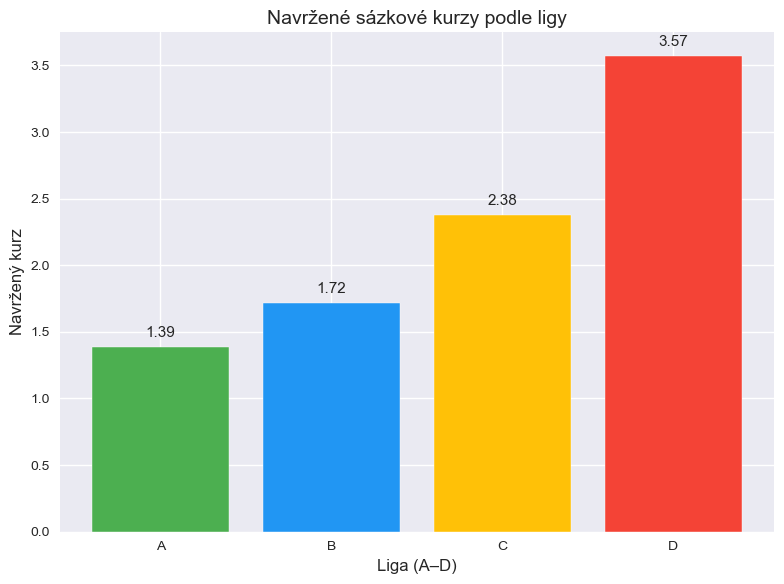

In [23]:
import matplotlib.pyplot as plt

# Data pro graf
leagues = ["A", "B", "C", "D"]
odds = [1.39, 1.72, 2.38, 3.57]

# Styl a velikost
plt.style.use("seaborn-v0_8")
plt.figure(figsize=(8, 6))

# Vykreslení sloupcového grafu
bars = plt.bar(leagues, odds, color=["#4CAF50", "#2196F3", "#FFC107", "#F44336"])

# Popisky os a název
plt.xlabel("Liga (A–D)", fontsize=12)
plt.ylabel("Navržený kurz", fontsize=12)
plt.title("Navržené sázkové kurzy podle ligy", fontsize=14)


# Přidání hodnot nad sloupce
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.05, f"{yval:.2f}", ha='center', va='bottom', fontsize=11)

# Zobrazení grafu
plt.tight_layout()
plt.show()


# Discussion

We have obtained certain odds values for each league. But how does this translate into real business? The entire task was about determining certain values from which a bookmaker can begin operations. Correct determination of these values is critical to attract customers to place bets with us, and on the other hand, inappropriate determination may lead to financial losses in the first days of operation.

For this reason, before translating the results and recommendations into business objectives, the analysis is subjected to discussion. Therefore, we will now take on a review role and would like to verify the steps. To that end, we will collectively discuss and critique our work by answering the following questions together:
- What elements of the analysis were simplified? What was omitted in the analysis?
- Are there any inconsistencies in the estimated odds? What are they?
- How can we improve the odds estimates?
- How can we enrich our initial dataset to make the estimates more accurate and less risky?
- How can we simulate the outcomes of our analysis to verify that they do not lead to financial losses?

This is a discussion panel, and every idea is valuable here.


In [ ]:
# Nechal jsem provést simulaci a bylo zjištěno, že by sázková kancelář dosáhla mírného zisku 5 479 Kč z celkových sázek ve výši 5,82 milionu Kč.
# Což považuji za nedostatečné. Musí dojít ke zvýšení marže a změně kurzů.
